# Distribution Analysis

Phân tích phân phối dữ liệu chi tiết và xử lý outliers cho các biến số

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, normaltest, kstest

In [2]:
# Load cleaned data
df = pd.read_csv('../data/youtube_clean.csv')

numerical_cols = ['duration', 'bitrate', 'bitrate(video)', 'height', 'width',
                  'frame rate', 'frame rate(est.)', 'views', 'likes', 'comments']

In [3]:
df[numerical_cols].describe()

,duration,bitrate,bitrate(video),height,width,frame rate,frame rate(est.),views,likes,comments
count,17586.000000,17586.000000,17586.000000,17586.000000,17586.000000,17586.000000,17586.000000,1.758600e+04,17586.000000,17586.000000
mean,241.373365,1271.605908,1154.970033,766.778460,504.596156,26.467321,9.472787,6.895334e+04,208.898158,12.901513
std,492.622456,1375.360511,1349.148185,467.327259,262.749959,6.040136,13.253750,3.537793e+06,8478.227399,225.858579
min,1.000000,41.000000,1.000000,108.000000,88.000000,3.750000,0.000000,0.000000e+00,0.000000,0.000000
25%,51.000000,437.000000,332.000000,426.000000,320.000000,25.000000,0.000000,3.800000e+01,0.000000,0.000000
50%,135.000000,743.750000,639.000000,640.000000,480.000000,29.970000,0.000000,1.530000e+02,1.000000,0.000000
75%,268.000000,1293.000000,1184.000000,960.000000,720.000000,29.970000,25.000000,8.000000e+02,4.000000,1.000000
max,25845.000000,22421.000000,22229.000000,2592.000000,1944.000000,59.080000,30.000000,4.103849e+08,836981.000000,16634.000000


## 1. Độ phân tán

Kiểm tra xem các biến có phân phối chuẩn (normal distribution) hay không.

In [4]:
for col in numerical_cols:
    col_range = df[col].max() - df[col].min()
    print(f"Range của {col}: {col_range}")

Range của duration: 25844
Range của bitrate: 22380.0
Range của bitrate(video): 22228.0
Range của height: 2484
Range của width: 1856
Range của frame rate: 55.33
Range của frame rate(est.): 30.0
Range của views: 410384910
Range của likes: 836981
Range của comments: 16634


In [5]:
print("Độ lệch chuẩn, phương sai và hệ số biến thiên của các cột số:")
for col in numerical_cols:
    std_dev = df[col].std()
    variance = df[col].var()
    mean = df[col].mean()
    cv = (std_dev / mean) * 100
    print(f"{col} - Độ lệch chuẩn: {std_dev:.2f}, phương sai: {variance:.2f}, Hệ số biến thiên: {cv:.2f}%")

Độ lệch chuẩn, phương sai và hệ số biến thiên của các cột số:
duration - Độ lệch chuẩn: 492.62, phương sai: 242676.88, Hệ số biến thiên: 204.09%
bitrate - Độ lệch chuẩn: 1375.36, phương sai: 1891616.54, Hệ số biến thiên: 108.16%
bitrate(video) - Độ lệch chuẩn: 1349.15, phương sai: 1820200.82, Hệ số biến thiên: 116.81%
height - Độ lệch chuẩn: 467.33, phương sai: 218394.77, Hệ số biến thiên: 60.95%
width - Độ lệch chuẩn: 262.75, phương sai: 69037.54, Hệ số biến thiên: 52.07%
frame rate - Độ lệch chuẩn: 6.04, phương sai: 36.48, Hệ số biến thiên: 22.82%
frame rate(est.) - Độ lệch chuẩn: 13.25, phương sai: 175.66, Hệ số biến thiên: 139.91%
views - Độ lệch chuẩn: 3537792.77, phương sai: 12515977670094.73, Hệ số biến thiên: 5130.71%
likes - Độ lệch chuẩn: 8478.23, phương sai: 71880339.83, Hệ số biến thiên: 4058.55%
comments - Độ lệch chuẩn: 225.86, phương sai: 51012.10, Hệ số biến thiên: 1750.64%


In [6]:
print("Interquartile Range (IQR) của các cột số:")
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    print(f"{col} - IQR: {IQR:.2f}")

Interquartile Range (IQR) của các cột số:
duration - IQR: 217.00
bitrate - IQR: 856.00
bitrate(video) - IQR: 852.00
height - IQR: 534.00
width - IQR: 400.00
frame rate - IQR: 4.97
frame rate(est.) - IQR: 25.00
views - IQR: 762.00
likes - IQR: 4.00
comments - IQR: 1.00


## 2. Outlier Detection

Phát hiện outliers sử dụng IQR method và Z-score method.

In [7]:
# Hàm phát hiện outliers bằng IQR
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Hàm phát hiện outliers bằng Z-score
def detect_outliers_zscore(data, column, threshold=3):
    z_scores = np.abs(stats.zscore(data[column].dropna()))
    outliers_idx = np.where(z_scores > threshold)[0]
    return data.iloc[outliers_idx]

# Phân tích outliers cho từng biến
outlier_summary = []

for col in numerical_cols:
    outliers_iqr, lower, upper = detect_outliers_iqr(df, col)
    outliers_z = detect_outliers_zscore(df, col)
    
    outlier_summary.append({
        'Variable': col,
        'Total Records': len(df),
        'Outliers (IQR)': len(outliers_iqr),
        'Outliers (Z-score)': len(outliers_z),
        'Outlier % (IQR)': round(len(outliers_iqr) / len(df) * 100, 2),
        'Lower Bound': round(lower, 2),
        'Upper Bound': round(upper, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
outlier_df

,Variable,Total Records,Outliers (IQR),Outliers (Z-score),Outlier % (IQR),Lower Bound,Upper Bound
0,duration,17586,1374,210,7.81,-274.50,593.50
1,bitrate,17586,2671,610,15.19,-847.00,2577.00
2,bitrate(video),17586,2603,614,14.80,-946.00,2462.00
3,height,17586,1366,3,7.77,-375.00,1761.00
4,width,17586,57,57,0.32,-280.00,1320.00
5,frame rate,17586,2287,403,13.00,17.55,37.42
6,frame rate(est.),17586,0,0,0.00,-37.50,62.50
7,views,17586,2888,8,16.42,-1105.00,1943.00
8,likes,17586,2565,10,14.59,-6.00,10.00
9,comments,17586,2424,62,13.78,-1.50,2.50


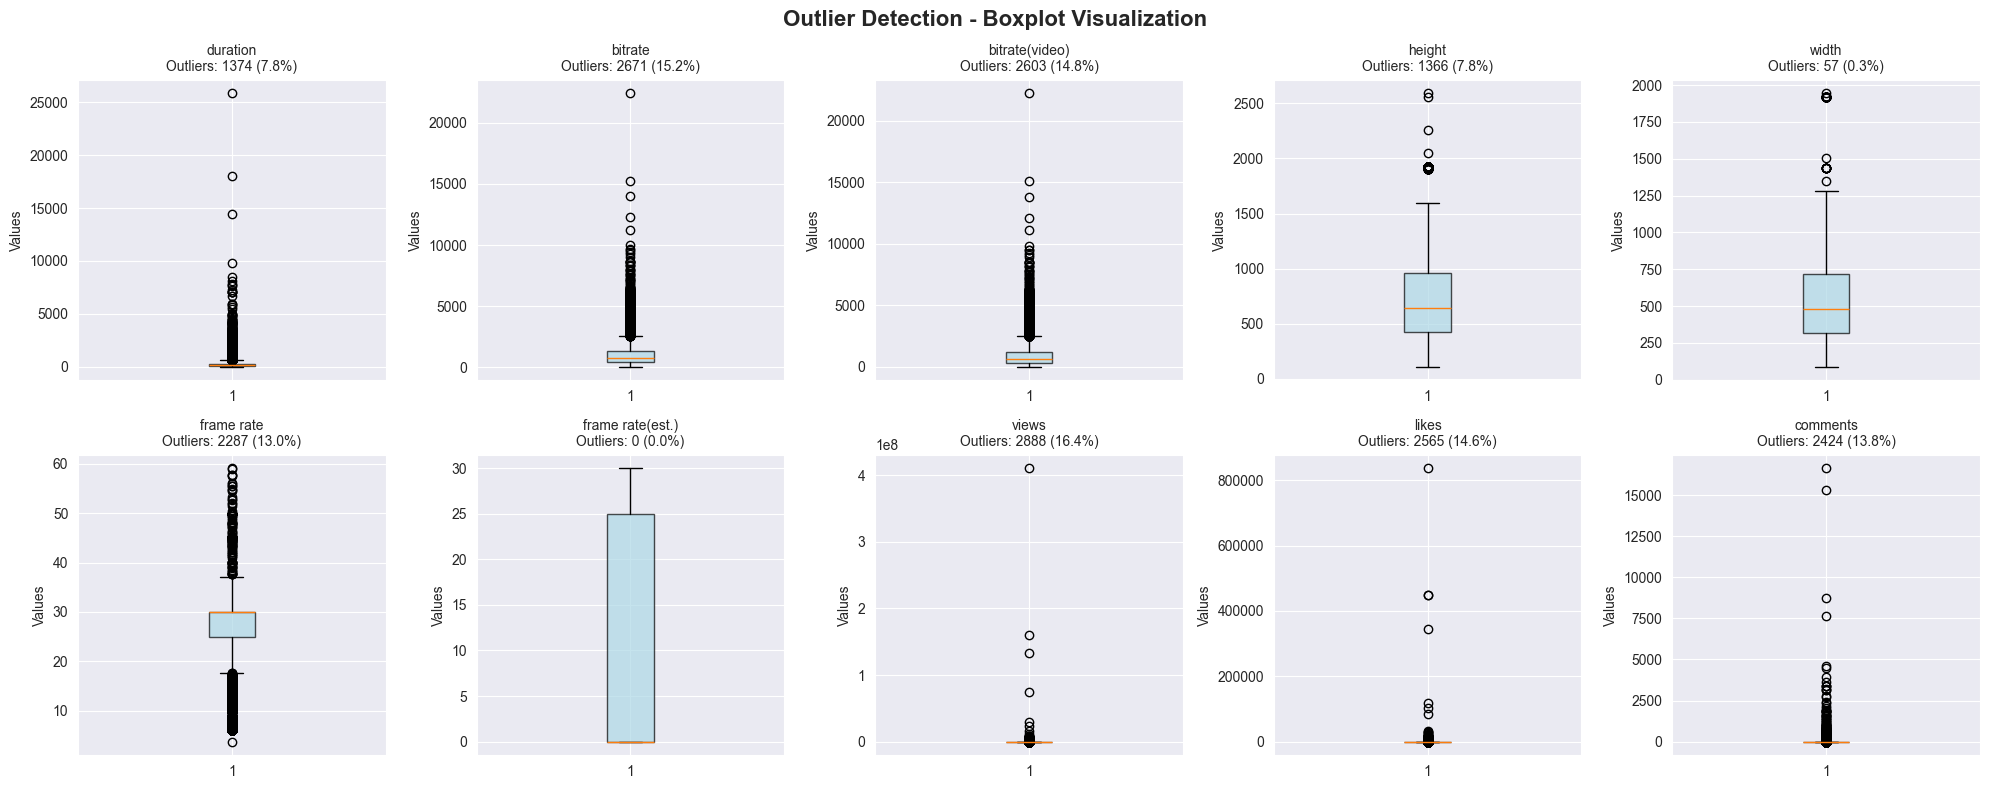

In [8]:
# Visualize outliers - Boxplot
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Outlier Detection - Boxplot Visualization', fontsize=16, fontweight='bold')

for idx, col in enumerate(numerical_cols):
    row = idx // 5
    col_idx = idx % 5
    
    ax = axes[row, col_idx]
    
    # Boxplot
    bp = ax.boxplot(df[col].dropna(), vert=True, patch_artist=True)
    bp['boxes'][0].set_facecolor('lightblue')
    bp['boxes'][0].set_alpha(0.7)
    
    # Thêm outlier count
    outliers_iqr, _, _ = detect_outliers_iqr(df, col)
    ax.set_title(f'{col}\nOutliers: {len(outliers_iqr)} ({len(outliers_iqr)/len(df)*100:.1f}%)', 
                 fontsize=10)
    ax.set_ylabel('Values')

plt.tight_layout()
plt.show()

## 3. Outlier Removal

Xử lý outliers cho các biến có tỷ lệ outliers cao (views, likes, comments).

In [9]:
df_no_outliers = df.copy()

for col in numerical_cols:
    df_no_outliers[f'{col}_log'] = np.log1p(df_no_outliers[col])

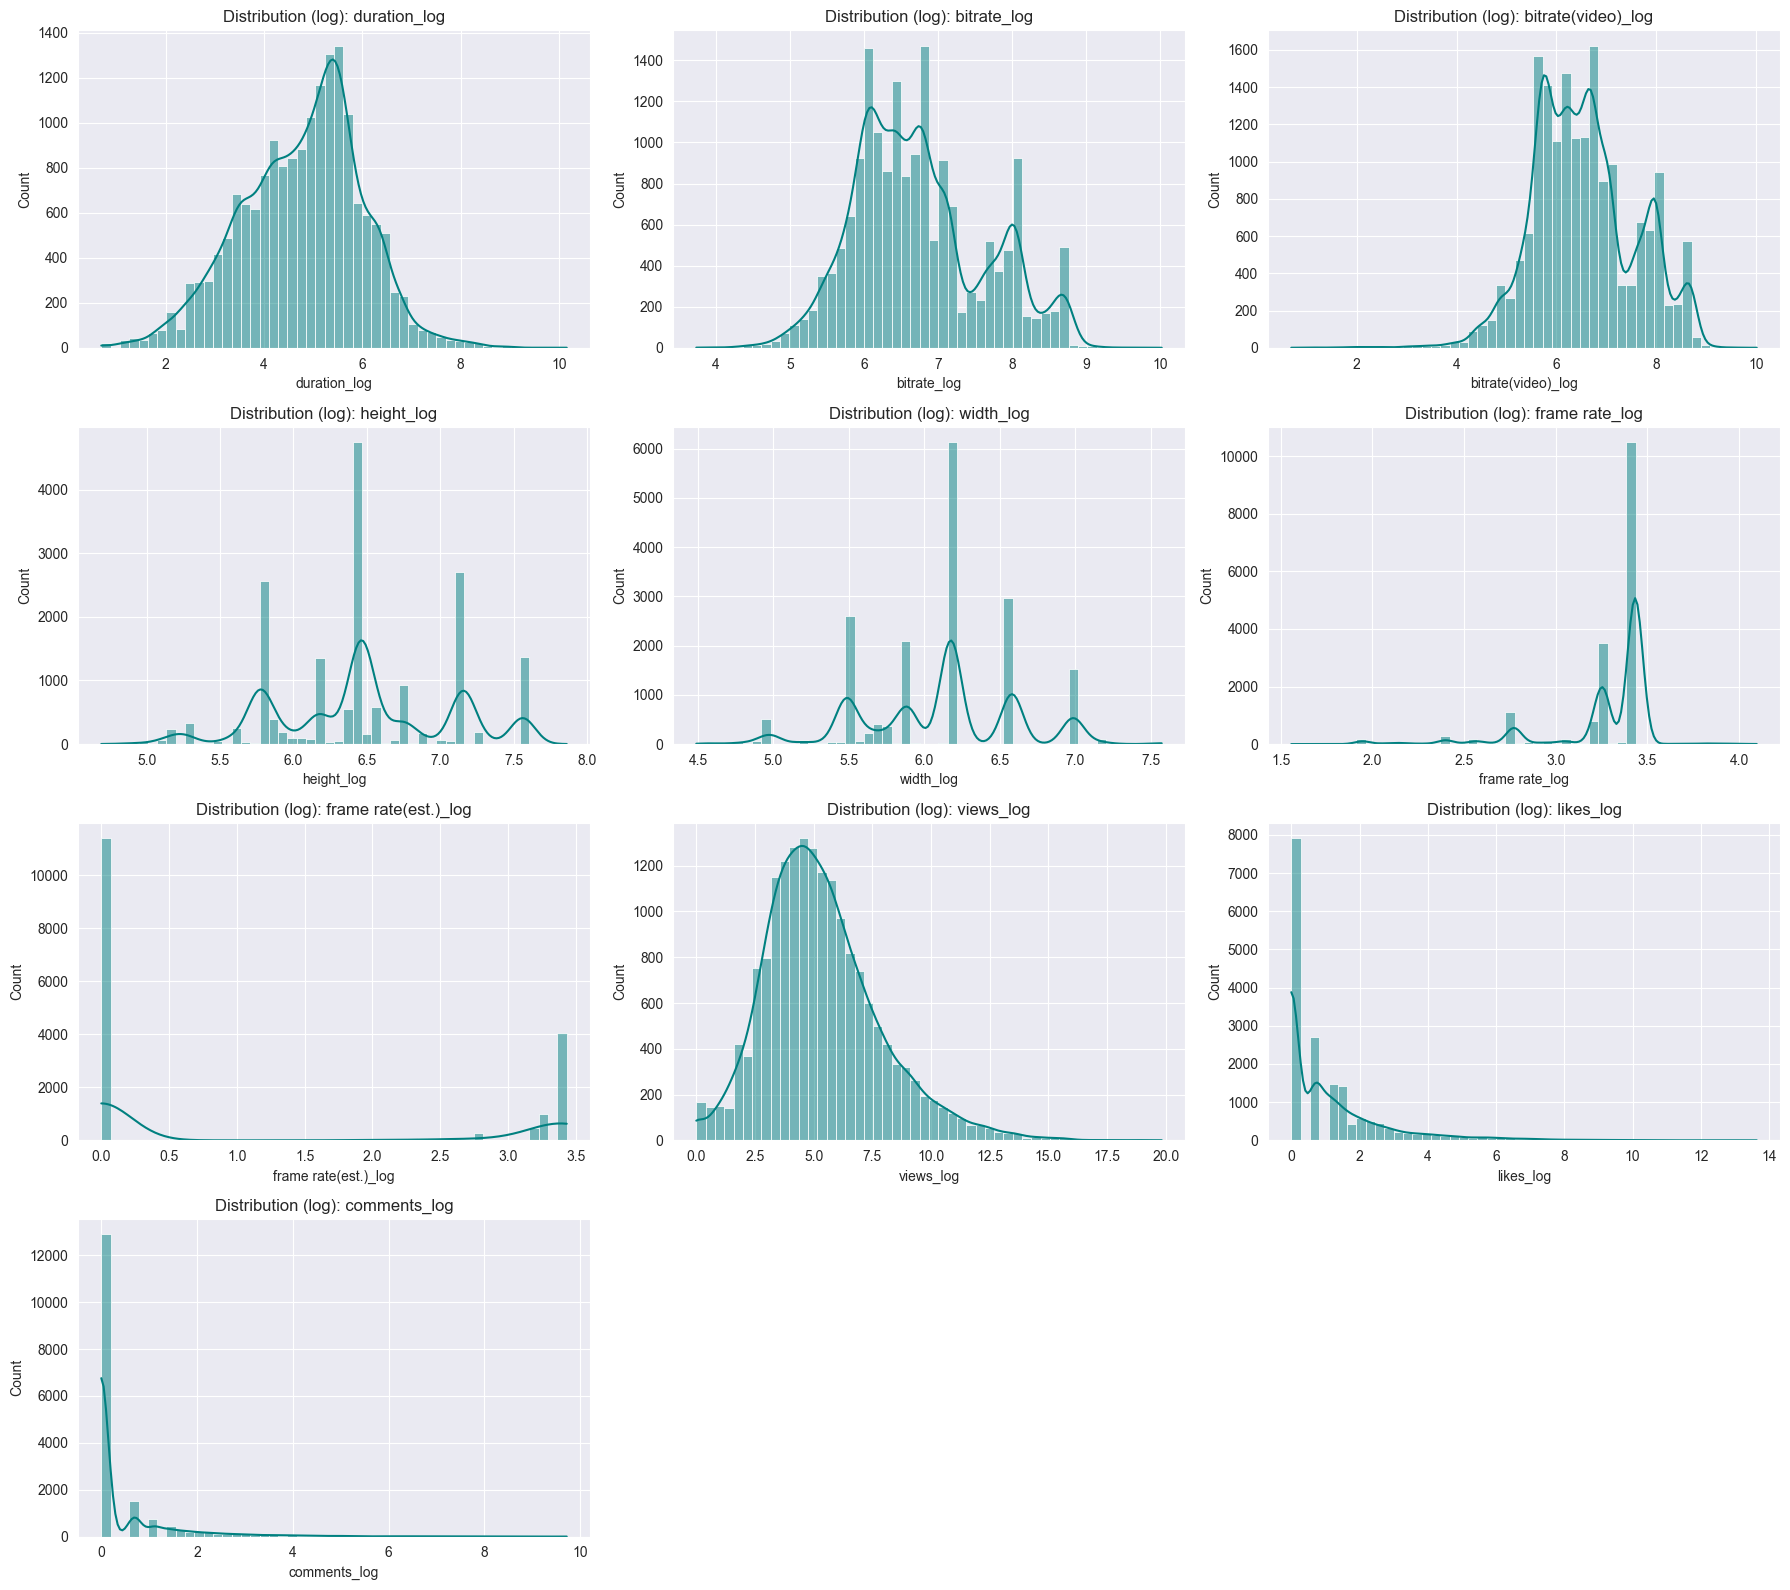

In [10]:
log_cols = [f"{col}_log" for col in numerical_cols]

fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(log_cols):
    sns.histplot(df_no_outliers[col], bins=50, kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f"Distribution (log): {col}")

for j in range(len(log_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

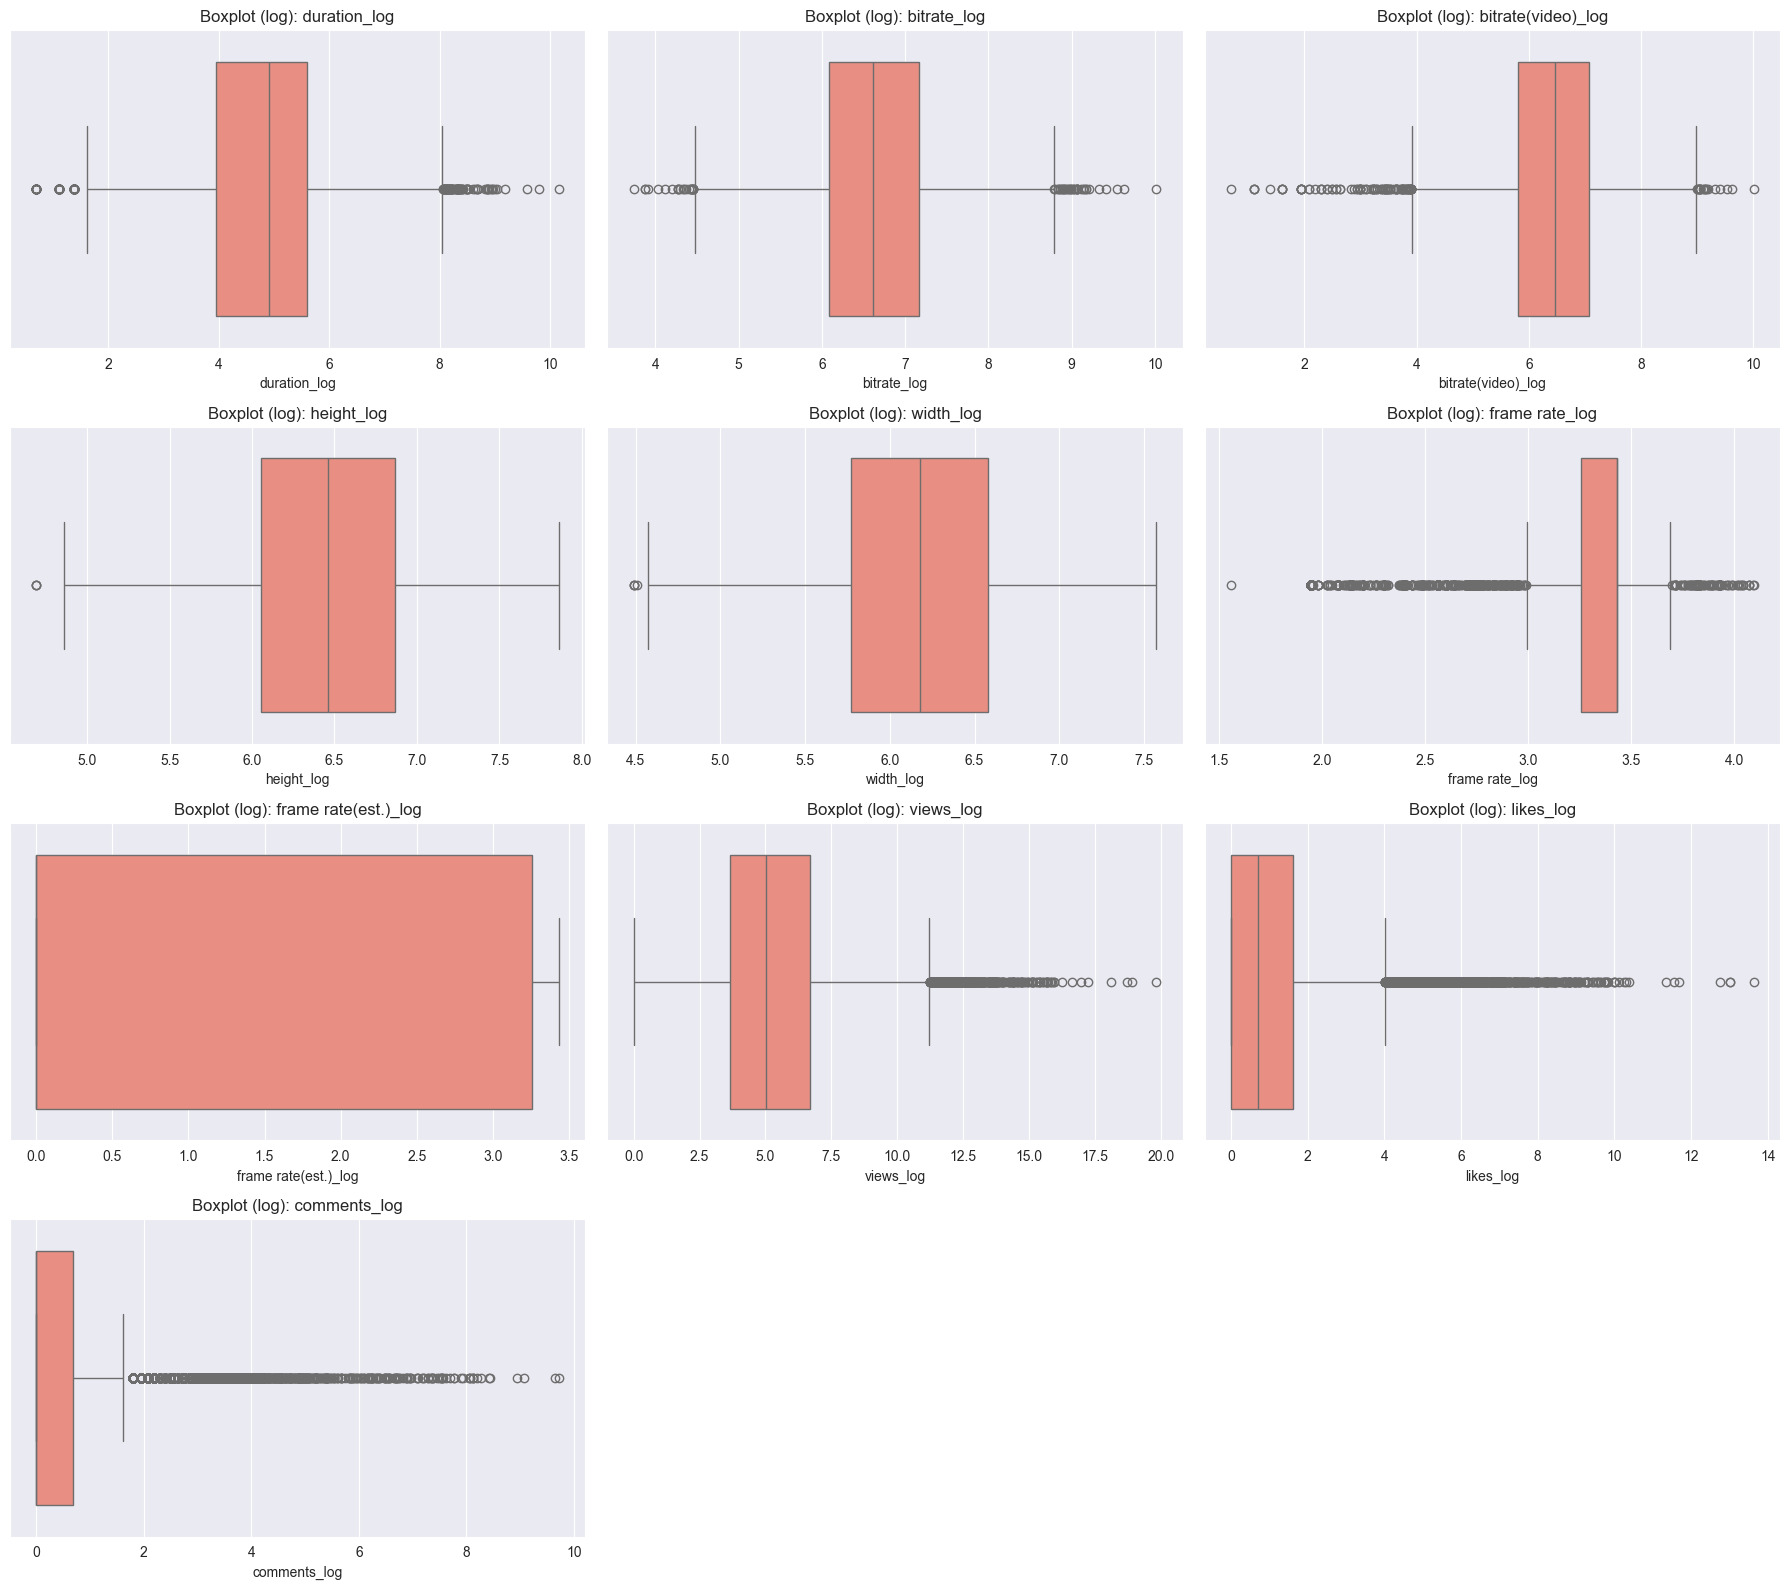

In [11]:
fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(18, 16))
axes = axes.flatten()

for i, col in enumerate(log_cols):
    sns.boxplot(x=df_no_outliers[col], ax=axes[i], color='salmon')
    axes[i].set_title(f"Boxplot (log): {col}")

# Remove empty plots
for j in range(len(log_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Sau khi thực hiện log-transform, phần lớn các biến (views_log, likes_log, comments_log) có phân phối gần chuẩn hơn, tuy nhiên vẫn tồn tại các giá trị ngoại lệ (2–10%). \
Với views_log, nhóm quyết định giữ nguyên vì đây có thể là các video nổi bật thực sự. \
Trong khi đó, likes_log và comments_log được xử lý bằng phương pháp Winsorization nhằm hạn chế ảnh hưởng của các giá trị cực trị đến mô hình hồi quy sau này.

In [12]:
def winsorize(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return np.clip(series, lower, upper)

for col in ['likes_log', 'comments_log', 'views_log']:
    df_no_outliers[f'{col}_win'] = winsorize(df_no_outliers[col])

In [14]:
compare_cols = [
    'likes_log', 'likes_log_win',
    'comments_log', 'comments_log_win',
    'views_log', 'views_log_win'
]

stats = df_no_outliers[compare_cols].describe().T
stats['skewness'] = df_no_outliers[compare_cols].skew()
stats['kurtosis'] = df_no_outliers[compare_cols].kurtosis()

stats[['mean','std','min','25%','50%','75%','max','skewness','kurtosis']]

,mean,std,min,25%,50%,75%,max,skewness,kurtosis
likes_log,1.104799,1.572682,0.0,0.000000,0.693147,1.609438,13.637558,2.203051,6.121292
likes_log_win,0.999454,1.235884,0.0,0.000000,0.693147,1.609438,4.023595,1.189646,0.353408
comments_log,0.469704,1.045420,0.0,0.000000,0.000000,0.693147,9.719264,3.202594,12.757901
comments_log_win,0.334514,0.600776,0.0,0.000000,0.000000,0.693147,1.732868,1.488986,0.601710
views_log,5.348244,2.474296,0.0,3.663562,5.036953,6.685861,19.832606,0.791246,1.179121
views_log_win,5.310173,2.360051,0.0,3.663562,5.036953,6.685861,11.219310,0.491563,0.033264


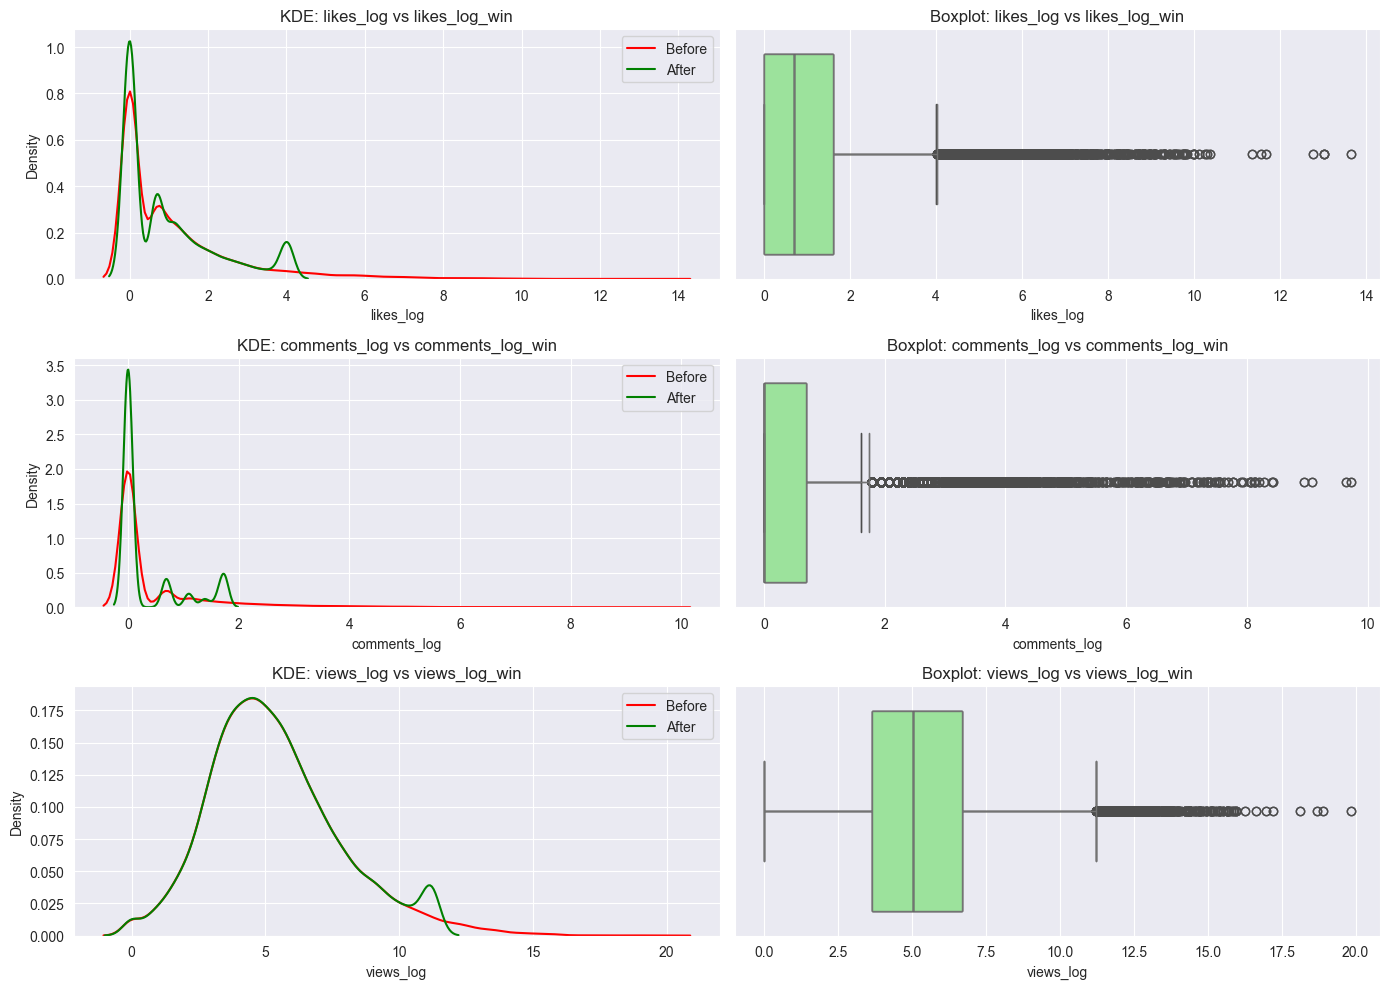

In [17]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))

pairs = [('likes_log', 'likes_log_win'),
         ('comments_log', 'comments_log_win'),
         ('views_log', 'views_log_win')]

for i, (raw, win) in enumerate(pairs):
    sns.kdeplot(df_no_outliers[raw], ax=axes[i, 0], label='Before', color='red')
    sns.kdeplot(df_no_outliers[win], ax=axes[i, 0], label='After', color='green')
    axes[i, 0].set_title(f"KDE: {raw} vs {win}")
    axes[i, 0].legend()

    sns.boxplot(x=df_no_outliers[raw], ax=axes[i, 1], color='orange')
    sns.boxplot(x=df_no_outliers[win], ax=axes[i, 1], color='lightgreen')
    axes[i, 1].set_title(f"Boxplot: {raw} vs {win}")

    sns.boxplot(x=df_no_outliers[raw], ax=axes[i, 1], color='orange')
    sns.boxplot(x=df_no_outliers[win], ax=axes[i, 1], color='lightgreen')
    axes[i, 1].set_title(f"Boxplot: {raw} vs {win}")


plt.tight_layout()
plt.show()

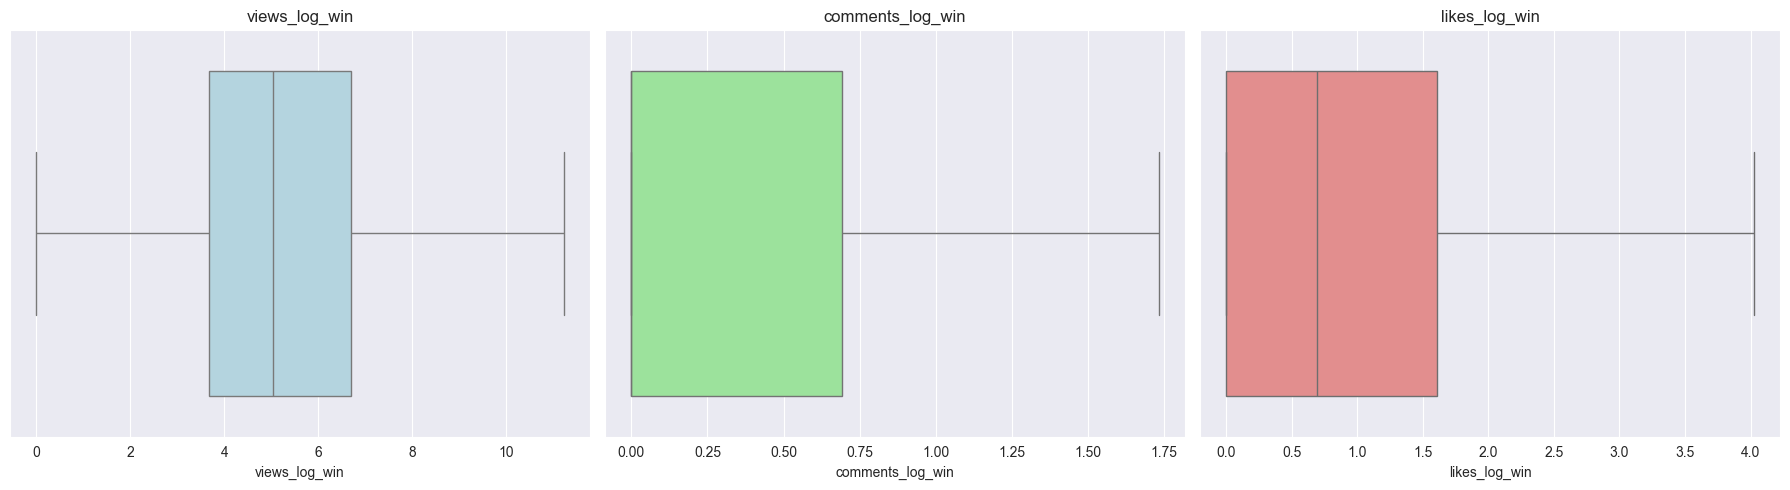

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x=df_no_outliers['views_log_win'], ax=axes[0], color='lightblue')
axes[0].set_title("views_log_win")

sns.boxplot(x=df_no_outliers['comments_log_win'], ax=axes[1], color='lightgreen')
axes[1].set_title("comments_log_win")

sns.boxplot(x=df_no_outliers['likes_log_win'], ax=axes[2], color='lightcoral')
axes[2].set_title("likes_log_win")

plt.tight_layout()
plt.show()

In [19]:
df_no_outliers

,duration,bitrate,bitrate(video),height,width,frame rate,frame rate(est.),codec,category,title,...,height_log,width_log,frame rate_log,frame rate(est.)_log,views_log,likes_log,comments_log,likes_log_win,comments_log_win,views_log_win
0,180,5777.0,5640.0,1920,1080,25.00,25.00,h264,News & Politics,«السودان ينتفض» أمام السفارة بالقاهرة,...,7.560601,6.985642,3.258097,3.258097,8.313607,3.737670,1.386294,3.737670,1.386294,8.313607
1,930,1195.0,1001.0,1280,720,30.00,30.00,h264,Gaming,Pokemon Tower Defense Episodio 2,...,7.155396,6.580639,3.433987,3.433987,3.526361,1.098612,0.693147,1.098612,0.693147,3.526361
2,233,3028.0,2833.0,1280,720,23.98,23.98,h264,Comedy,New Hip Hop - Kemo Treats - Pancakes,...,7.155396,6.580639,3.218076,3.218076,9.490091,4.912655,2.890372,4.023595,1.732868,9.490091
3,562,431.0,300.0,320,240,29.97,0.00,h264,People & Blogs,Sister's Keeper Impression,...,5.771441,5.484797,3.433019,0.000000,3.784190,0.693147,0.000000,0.693147,0.000000,3.784190
4,300,3087.0,2929.0,1280,720,23.98,23.98,h264,Gaming,JBHAMMER777 (AKUMA) VS KtossPol Rank 1 (Vega)...,...,7.155396,6.580639,3.218076,3.218076,5.407172,1.098612,0.000000,1.098612,0.000000,5.407172
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17581,571,1285.0,1175.0,640,480,29.92,0.00,h264,People & Blogs,rentero 1ª parte 2.MOD,...,6.463029,6.175867,3.431403,0.000000,3.332205,0.000000,0.000000,0.000000,0.000000,3.332205
17582,105,840.0,719.0,640,480,29.97,0.00,h264,People & Blogs,Cascavel faz campanha impecável em campeonato ...,...,6.463029,6.175867,3.433019,0.000000,5.690359,0.693147,0.000000,0.693147,0.000000,5.690359
17583,161,920.0,820.0,640,480,29.97,0.00,h264,People & Blogs,Marcha para Cristo.San Francisco Menéndez. 5 ...,...,6.463029,6.175867,3.433019,0.000000,6.647688,1.386294,0.000000,1.386294,0.000000,6.647688
17584,291,4892.0,4738.0,1920,1080,29.97,29.97,h264,Gaming,DK Solo Steinerne Kern,...,7.560601,6.985642,3.433019,3.433019,3.761200,0.693147,0.000000,0.693147,0.000000,3.761200


In [21]:
# Save cleaned data
df_no_outliers.to_csv('../data/youtube_no_outliers_clean_final_v2.csv', index=False)

**Normality Tests:**
- Hầu hết biến **không có phân phối chuẩn** (p-value < 0.05)
- Views, likes, comments có phân phối highly skewed

**Outlier Removal:**
- Loại bỏ outliers cho: views, likes, comments
- Giữ nguyên các biến technical (duration, bitrate, height, width, frame rate)
- Data sau khi xử lý: **youtube_no_outliers_clean_final.csv**

**Next Steps:**
- Correlation Analysis với data đã clean
- ANOVA Analysis để so sánh giữa các category